## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

In [ ]:
%autosave 60

Autosaving every 60 seconds


In [9]:
import pandas as pd

drinks = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
drinks.head()



,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9


## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [10]:
drinks.drop(["total_litres_of_pure_alcohol"], axis=1, inplace=True) #run it once

In [11]:
drinks.columns

tidy_drinks = pd.melt(
    drinks,
    id_vars=["country"],
    var_name="drink",
    value_name="servings"
)

print(drinks)
print("-----------------------------------------")
print(tidy_drinks)






         country  beer_servings  spirit_servings  wine_servings
0    Afghanistan              0                0              0
1        Albania             89              132             54
2        Algeria             25                0             14
3        Andorra            245              138            312
4         Angola            217               57             45
..           ...            ...              ...            ...
188    Venezuela            333              100              3
189      Vietnam            111                2              1
190        Yemen              6                0              0
191       Zambia             32               19              4
192     Zimbabwe             64               18              4

[193 rows x 4 columns]
-----------------------------------------
         country          drink  servings
0    Afghanistan  beer_servings         0
1        Albania  beer_servings        89
2        Algeria  beer_servings        2

## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

In [12]:
tidy_drinks["drink"] = tidy_drinks["drink"].str.replace("_servings", "", regex=False)
tidy_drinks.head()



,country,drink,servings
0,Afghanistan,beer,0
1,Albania,beer,89
2,Algeria,beer,25
3,Andorra,beer,245
4,Angola,beer,217


Namibia drinks the most beer
Grenada drinks the most spirit
France drinks the most wine


Text(0.5, 1.0, 'Top 10 Wine Drinking Countries')

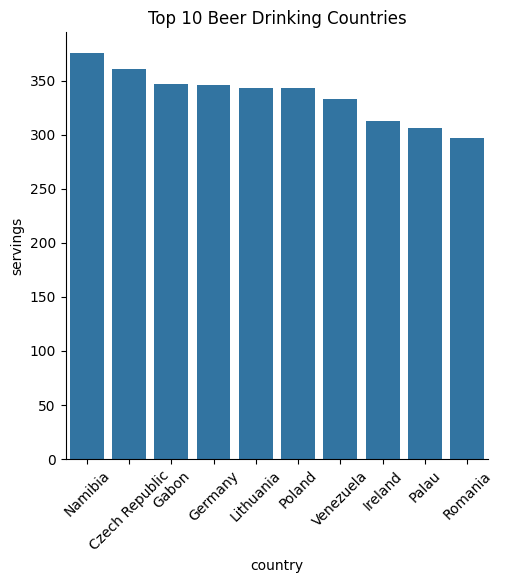

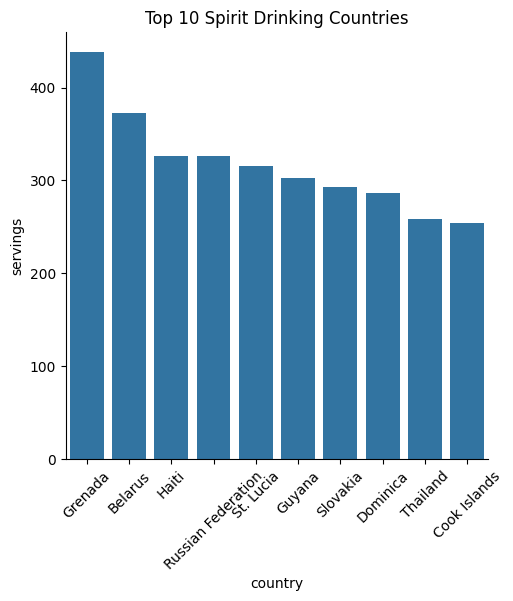

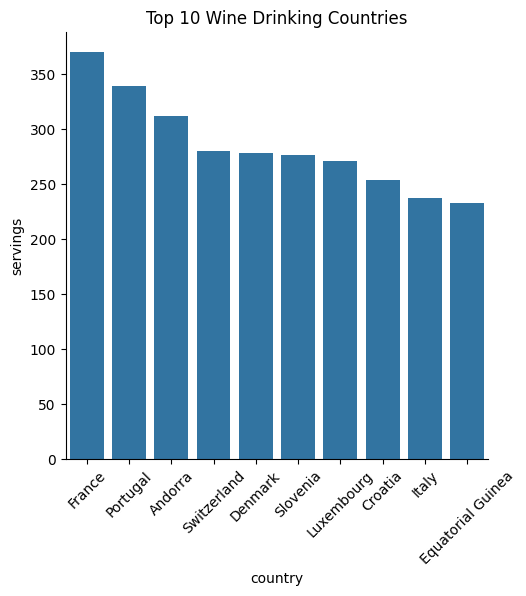

In [13]:
most_beer = tidy_drinks.loc[tidy_drinks[tidy_drinks["drink"] == "beer"]["servings"].idxmax(), "country"]
most_spirit = tidy_drinks.loc[tidy_drinks[tidy_drinks["drink"] == "spirit"]["servings"].idxmax(), "country"]
most_wine = tidy_drinks.loc[tidy_drinks[tidy_drinks["drink"] == "wine"]["servings"].idxmax(), "country"]

print(most_beer, "drinks the most beer")
print(most_spirit, "drinks the most spirit")
print(most_wine, "drinks the most wine")

import seaborn as sns
import matplotlib.pyplot as plt

top_beer = tidy_drinks[tidy_drinks["drink"] == "beer"].sort_values("servings", ascending=False).head(10)
top_spirit = tidy_drinks[tidy_drinks["drink"] == "spirit"].sort_values("servings", ascending=False).head(10)
top_wine = tidy_drinks[tidy_drinks["drink"] == "wine"].sort_values("servings", ascending=False).head(10)

sns.catplot(data=top_beer, x="country", y="servings", kind="bar")
plt.xticks(rotation=45)
plt.title("Top 10 Beer Drinking Countries")

sns.catplot(data=top_spirit, x="country", y="servings", kind="bar")
plt.xticks(rotation=45)
plt.title("Top 10 Spirit Drinking Countries")

sns.catplot(data=top_wine, x="country", y="servings", kind="bar")
plt.xticks(rotation=45)
plt.title("Top 10 Wine Drinking Countries")


## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

In [14]:
wide_df = tidy_drinks.pivot_table(
    index="country",
    columns="drink",
    values="servings"
).reset_index()

wide_df.head()


drink,country,beer,spirit,wine
0,Afghanistan,0.0,0.0,0.0
1,Albania,89.0,132.0,54.0
2,Algeria,25.0,0.0,14.0
3,Andorra,245.0,138.0,312.0
4,Angola,217.0,57.0,45.0
